In [1]:
# ============================================================
# 1) Install required packages
# ============================================================
import sys
import subprocess
import importlib.util

def ensure_package(import_name: str, pip_name: str) -> None:
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", pip_name]
        )

ensure_package("gymnasium", "gymnasium[classic-control]")
ensure_package("matplotlib", "matplotlib")
ensure_package("imageio", "imageio")
ensure_package("imageio_ffmpeg", "imageio-ffmpeg")


In [ ]:
# ============================================================
# 2) Imports, configuration, device and reproducibility
# ============================================================
import csv
import math
import random
from dataclasses import dataclass
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.normal import Normal

try:
    from IPython.display import Video, display
except Exception:
    Video = None
    display = None


@dataclass
class PPOConfig:
    env_id: str = "Pendulum-v1"
    seed: int = 7

    # Maximum training budget
    total_timesteps: int = 700_000
    rollout_steps: int = 2048
    update_epochs: int = 10
    minibatch_size: int = 64

    # PPO / GAE
    gamma: float = 0.99
    gae_lambda: float = 0.95
    clip_coef: float = 0.20
    vf_coef: float = 0.50
    ent_coef: float = 0.001
    max_grad_norm: float = 0.50
    target_kl: float = 0.03

    # Optimizer
    learning_rate: float = 3e-4
    anneal_lr: bool = True
    reward_scale: float = 0.10

    # Network
    hidden_size: int = 128
    init_log_std: float = -0.5

    # Evaluation
    eval_every_updates: int = 10
    eval_episodes: int = 20
    target_mean_reward: float = -180.0
    stable_evaluations_required: int = 3
    min_updates_before_early_stop: int = 50

    # Final evaluation
    final_eval_episodes: int = 50
    final_blocks: int = 5
    final_min_blocks_meeting_target: int = 4

    save_dir: str = "ppo_pendulum_outputs_corrected"


cfg = PPOConfig()
output_dir = Path(cfg.save_dir)
output_dir.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

set_seed(cfg.seed)

print("=" * 82)
print("Manual PPO for Gymnasium Pendulum-v1")
print("Device:", device)
print("Maximum training timesteps:", cfg.total_timesteps)
print("Output directory:", output_dir.resolve())
print("=" * 82)


Manual PPO for Gymnasium Pendulum-v1
Device: cuda
Maximum training timesteps: 700000
Output directory: /content/ppo_pendulum_outputs_corrected


In [ ]:
# ============================================================
# 3) Environment helpers and Actor-Critic network
# ============================================================
def make_env(render_mode=None):
    env = gym.make(cfg.env_id, render_mode=render_mode)
    env.action_space.seed(cfg.seed)
    env.observation_space.seed(cfg.seed)
    return env


env = make_env()
obs_dim = int(env.observation_space.shape[0])
act_dim = int(env.action_space.shape[0])

action_low_np = env.action_space.low.astype(np.float32)
action_high_np = env.action_space.high.astype(np.float32)

action_scale_np = (action_high_np - action_low_np) / 2.0
action_bias_np = (action_high_np + action_low_np) / 2.0

print("Observation dimension:", obs_dim)
print("Action dimension:", act_dim)
print("Action range:", (action_low_np, action_high_np))


def layer_init(layer: nn.Linear, std: float = math.sqrt(2), bias_const: float = 0.0):
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer


class ActorCritic(nn.Module):

    def __init__(
        self,
        obs_dim: int,
        act_dim: int,
        hidden_size: int,
        action_scale,
        action_bias,
        init_log_std: float,
    ):
        super().__init__()

        self.actor_mean = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden_size)),
            nn.Tanh(),
            layer_init(nn.Linear(hidden_size, hidden_size)),
            nn.Tanh(),
            layer_init(nn.Linear(hidden_size, act_dim), std=0.01),
        )

        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden_size)),
            nn.Tanh(),
            layer_init(nn.Linear(hidden_size, hidden_size)),
            nn.Tanh(),
            layer_init(nn.Linear(hidden_size, 1), std=1.0),
        )

        self.log_std = nn.Parameter(
            torch.full((1, act_dim), float(init_log_std), dtype=torch.float32)
        )

        self.register_buffer(
            "action_scale",
            torch.as_tensor(action_scale, dtype=torch.float32).reshape(1, -1),
        )
        self.register_buffer(
            "action_bias",
            torch.as_tensor(action_bias, dtype=torch.float32).reshape(1, -1),
        )

    def get_dist(self, obs: torch.Tensor) -> Normal:
        mean = self.actor_mean(obs)
        log_std = torch.clamp(self.log_std.expand_as(mean), min=-5.0, max=1.0)
        return Normal(mean, torch.exp(log_std))

    def squash_action(self, raw_action: torch.Tensor) -> torch.Tensor:
        return torch.tanh(raw_action) * self.action_scale + self.action_bias

    def corrected_log_prob(
        self,
        dist: Normal,
        raw_action: torch.Tensor,
    ) -> torch.Tensor:
        log_prob_raw = dist.log_prob(raw_action).sum(dim=-1)
        tanh_raw = torch.tanh(raw_action)

        correction = torch.log(
            self.action_scale * (1.0 - tanh_raw.pow(2)) + 1e-6
        ).sum(dim=-1)

        return log_prob_raw - correction

    def get_action_and_value(
        self,
        obs: torch.Tensor,
        raw_action: torch.Tensor | None = None,
    ):
        dist = self.get_dist(obs)

        if raw_action is None:
            raw_action = dist.rsample()

        env_action = self.squash_action(raw_action)
        log_prob = self.corrected_log_prob(dist, raw_action)
        entropy = dist.entropy().sum(dim=-1)
        value = self.critic(obs).squeeze(-1)

        return env_action, log_prob, entropy, value, raw_action

    @torch.no_grad()
    def deterministic_action(self, obs: torch.Tensor) -> torch.Tensor:
        raw_mean = self.actor_mean(obs)
        return self.squash_action(raw_mean)


agent = ActorCritic(
    obs_dim=obs_dim,
    act_dim=act_dim,
    hidden_size=cfg.hidden_size,
    action_scale=action_scale_np,
    action_bias=action_bias_np,
    init_log_std=cfg.init_log_std,
).to(device)

optimizer = optim.Adam(
    agent.parameters(),
    lr=cfg.learning_rate,
    eps=1e-5,
)

print(agent)


Observation dimension: 3
Action dimension: 1
Action range: (array([-2.], dtype=float32), array([2.], dtype=float32))
ActorCritic(
  (actor_mean): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
  (critic): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [4]:
# ============================================================
# 4) Deterministic evaluation
# ============================================================
@torch.no_grad()
def evaluate_policy(
    model: ActorCritic,
    episodes: int,
    seed_start: int,
    deterministic: bool = True,
    render_video_path: str | None = None,
):
    render_mode = "rgb_array" if render_video_path is not None else None
    eval_env = make_env(render_mode=render_mode)

    scores = []
    frames = []

    for episode_index in range(episodes):
        obs, _ = eval_env.reset(seed=seed_start + episode_index)
        episode_done = False
        episode_reward = 0.0

        while not episode_done:
            obs_tensor = torch.as_tensor(
                obs,
                dtype=torch.float32,
                device=device,
            ).unsqueeze(0)

            if deterministic:
                action_tensor = model.deterministic_action(obs_tensor)
            else:
                action_tensor, _, _, _, _ = model.get_action_and_value(obs_tensor)

            action = action_tensor.squeeze(0).cpu().numpy()

            obs, reward, terminated, truncated, _ = eval_env.step(action)
            episode_done = bool(terminated or truncated)
            episode_reward += float(reward)

            if render_video_path is not None:
                frame = eval_env.render()
                if frame is not None:
                    frames.append(frame)

        scores.append(episode_reward)

    eval_env.close()

    if render_video_path is not None and frames:
        imageio.mimsave(render_video_path, frames, fps=30)

    scores_array = np.asarray(scores, dtype=np.float64)

    return {
        "mean": float(scores_array.mean()),
        "std": float(scores_array.std(ddof=0)),
        "median": float(np.median(scores_array)),
        "minimum": float(scores_array.min()),
        "maximum": float(scores_array.max()),
        "scores": scores_array,
        "target_rate": float(np.mean(scores_array >= cfg.target_mean_reward)),
    }


def load_state_dict_safely(path: Path):
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=device)


In [ ]:
# ============================================================
# 5) PPO training with correct episode-boundary handling
# ============================================================
num_updates = cfg.total_timesteps // cfg.rollout_steps

obs_buf = torch.zeros(
    (cfg.rollout_steps, obs_dim),
    dtype=torch.float32,
    device=device,
)
next_obs_transition_buf = torch.zeros_like(obs_buf)

raw_actions_buf = torch.zeros(
    (cfg.rollout_steps, act_dim),
    dtype=torch.float32,
    device=device,
)
logprobs_buf = torch.zeros(cfg.rollout_steps, dtype=torch.float32, device=device)
rewards_buf = torch.zeros_like(logprobs_buf)
values_buf = torch.zeros_like(logprobs_buf)

episode_ends_buf = torch.zeros_like(logprobs_buf)

terminated_buf = torch.zeros_like(logprobs_buf)


global_step = 0
episode_rewards = []
eval_history = []

next_obs_np, _ = env.reset(seed=cfg.seed)
next_obs = torch.as_tensor(next_obs_np, dtype=torch.float32, device=device)

current_episode_reward = 0.0
best_eval_mean = -float("inf")
best_update = None
stable_eval_count = 0
stable_convergence_update = None

best_model_path = output_dir / "best_ppo_pendulum.pt"
last_model_path = output_dir / "last_ppo_pendulum.pt"

print("\nStarting PPO training...\n")

for update in range(1, num_updates + 1):
    if cfg.anneal_lr:
        fraction_remaining = 1.0 - (update - 1.0) / num_updates
        optimizer.param_groups[0]["lr"] = fraction_remaining * cfg.learning_rate


    for step in range(cfg.rollout_steps):
        global_step += 1
        obs_buf[step] = next_obs

        with torch.no_grad():
            env_action, log_prob, _, value, raw_action = (
                agent.get_action_and_value(next_obs.unsqueeze(0))
            )

        values_buf[step] = value.squeeze(0)
        logprobs_buf[step] = log_prob.squeeze(0)
        raw_actions_buf[step] = raw_action.squeeze(0)

        action_np = env_action.squeeze(0).cpu().numpy()

        (
            transition_next_obs_np,
            reward,
            terminated,
            truncated,
            _,
        ) = env.step(action_np)

        episode_end = bool(terminated or truncated)

        transition_next_obs = torch.as_tensor(
            transition_next_obs_np,
            dtype=torch.float32,
            device=device,
        )

        next_obs_transition_buf[step] = transition_next_obs
        rewards_buf[step] = float(reward) * cfg.reward_scale
        episode_ends_buf[step] = float(episode_end)
        terminated_buf[step] = float(terminated)

        current_episode_reward += float(reward)

        if episode_end:
            episode_rewards.append(current_episode_reward)
            current_episode_reward = 0.0

            reset_obs_np, _ = env.reset()
            next_obs = torch.as_tensor(
                reset_obs_np,
                dtype=torch.float32,
                device=device,
            )
        else:
            next_obs = transition_next_obs

    # --------------------------------------------------------
    # Correct GAE computation
    # --------------------------------------------------------
    with torch.no_grad():
        next_values = agent.critic(next_obs_transition_buf).squeeze(-1)

        next_values = next_values * (1.0 - terminated_buf)

        advantages = torch.zeros_like(rewards_buf)
        last_gae = torch.tensor(0.0, device=device)

        for t in reversed(range(cfg.rollout_steps)):
            td_delta = (
                rewards_buf[t]
                + cfg.gamma * next_values[t]
                - values_buf[t]
            )

            continue_same_episode = 1.0 - episode_ends_buf[t]

            last_gae = (
                td_delta
                + cfg.gamma
                * cfg.gae_lambda
                * continue_same_episode
                * last_gae
            )
            advantages[t] = last_gae

        returns = advantages + values_buf

    normalized_advantages = (
        advantages - advantages.mean()
    ) / (advantages.std(unbiased=False) + 1e-8)

    # --------------------------------------------------------
    # PPO update
    # --------------------------------------------------------
    batch_indices = np.arange(cfg.rollout_steps)
    update_clip_fractions = []
    update_kls = []
    last_policy_loss = float("nan")
    last_value_loss = float("nan")
    last_entropy = float("nan")
    stop_for_kl = False

    for epoch in range(cfg.update_epochs):
        np.random.shuffle(batch_indices)
        epoch_kls = []

        for start in range(0, cfg.rollout_steps, cfg.minibatch_size):
            minibatch_indices = batch_indices[
                start : start + cfg.minibatch_size
            ]

            _, new_log_prob, entropy, new_value, _ = (
                agent.get_action_and_value(
                    obs_buf[minibatch_indices],
                    raw_actions_buf[minibatch_indices],
                )
            )

            log_ratio = new_log_prob - logprobs_buf[minibatch_indices]
            ratio = log_ratio.exp()

            with torch.no_grad():
                approx_kl = ((ratio - 1.0) - log_ratio).mean()
                clip_fraction = (
                    (ratio - 1.0).abs() > cfg.clip_coef
                ).float().mean()

                epoch_kls.append(float(approx_kl.item()))
                update_kls.append(float(approx_kl.item()))
                update_clip_fractions.append(float(clip_fraction.item()))

            minibatch_advantages = normalized_advantages[minibatch_indices]

            policy_loss_unclipped = -minibatch_advantages * ratio
            policy_loss_clipped = (
                -minibatch_advantages
                * torch.clamp(
                    ratio,
                    1.0 - cfg.clip_coef,
                    1.0 + cfg.clip_coef,
                )
            )
            policy_loss = torch.max(
                policy_loss_unclipped,
                policy_loss_clipped,
            ).mean()

            new_value = new_value.view(-1)
            value_loss_unclipped = (
                new_value - returns[minibatch_indices]
            ).pow(2)

            clipped_value = (
                values_buf[minibatch_indices]
                + torch.clamp(
                    new_value - values_buf[minibatch_indices],
                    -cfg.clip_coef,
                    cfg.clip_coef,
                )
            )
            value_loss_clipped = (
                clipped_value - returns[minibatch_indices]
            ).pow(2)

            value_loss = 0.5 * torch.max(
                value_loss_unclipped,
                value_loss_clipped,
            ).mean()

            entropy_mean = entropy.mean()

            total_loss = (
                policy_loss
                + cfg.vf_coef * value_loss
                - cfg.ent_coef * entropy_mean
            )

            optimizer.zero_grad(set_to_none=True)
            total_loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), cfg.max_grad_norm)
            optimizer.step()

            last_policy_loss = float(policy_loss.item())
            last_value_loss = float(value_loss.item())
            last_entropy = float(entropy_mean.item())

        mean_epoch_kl = float(np.mean(epoch_kls)) if epoch_kls else 0.0

        if mean_epoch_kl > cfg.target_kl:
            stop_for_kl = True
            break

    recent_train_mean = (
        float(np.mean(episode_rewards[-10:]))
        if episode_rewards
        else float("nan")
    )

    mean_update_kl = (
        float(np.mean(update_kls))
        if update_kls
        else float("nan")
    )
    mean_clip_fraction = (
        float(np.mean(update_clip_fractions))
        if update_clip_fractions
        else float("nan")
    )

    should_evaluate = (
        update == 1
        or update % cfg.eval_every_updates == 0
    )

    if should_evaluate:
        evaluation = evaluate_policy(
            agent,
            episodes=cfg.eval_episodes,
            seed_start=10_000,
            deterministic=True,
        )

        eval_mean = evaluation["mean"]
        eval_std = evaluation["std"]
        target_rate = evaluation["target_rate"]

        meets_target = eval_mean >= cfg.target_mean_reward
        stable_eval_count = stable_eval_count + 1 if meets_target else 0

        eval_history.append(
            {
                "update": update,
                "global_step": global_step,
                "mean_reward": eval_mean,
                "std_reward": eval_std,
                "median_reward": evaluation["median"],
                "target_rate": target_rate,
                "stable_count": stable_eval_count,
            }
        )

        if eval_mean > best_eval_mean:
            best_eval_mean = eval_mean
            best_update = update
            torch.save(agent.state_dict(), best_model_path)
            best_message = " | NEW BEST"
        else:
            best_message = ""

        print(
            f"EVAL  | update {update:4d}/{num_updates} | "
            f"step {global_step:7d} | "
            f"train_avg10 {recent_train_mean:8.2f} | "
            f"eval {eval_mean:8.2f} ± {eval_std:7.2f} | "
            f"target_rate {100.0 * target_rate:6.1f}% | "
            f"stable {stable_eval_count}/{cfg.stable_evaluations_required} | "
            f"KL {mean_update_kl:.5f} | "
            f"clip {mean_clip_fraction:.3f}"
            f"{best_message}"
        )

        if (
            update >= cfg.min_updates_before_early_stop
            and stable_eval_count >= cfg.stable_evaluations_required
        ):
            stable_convergence_update = update
            print(
                "\nStable convergence detected after "
                f"{cfg.stable_evaluations_required} "
                "consecutive deterministic evaluations."
            )
            break

    else:
        print(
            f"TRAIN | update {update:4d}/{num_updates} | "
            f"step {global_step:7d} | "
            f"train_avg10 {recent_train_mean:8.2f} | "
            f"policy_loss {last_policy_loss:8.4f} | "
            f"value_loss {last_value_loss:8.4f} | "
            f"entropy {last_entropy:7.4f} | "
            f"KL {mean_update_kl:.5f}"
            + (" | KL EARLY STOP" if stop_for_kl else "")
        )


env.close()

torch.save(agent.state_dict(), last_model_path)

if not best_model_path.exists():
    torch.save(agent.state_dict(), best_model_path)
    best_eval_mean = float("nan")
    best_update = update

agent.load_state_dict(load_state_dict_safely(best_model_path))

print("\nTraining finished.")
print("Completed updates:", update)
print("Completed environment steps:", global_step)
print("Best checkpoint update:", best_update)
print("Best checkpoint mean reward:", best_eval_mean)
print("Stable convergence update:", stable_convergence_update)
print("Best model:", best_model_path)
print("Last model:", last_model_path)



Starting PPO training...

EVAL  | update    1/341 | step    2048 | train_avg10 -1198.16 | eval -1171.75 ±  252.36 | target_rate    0.0% | stable 0/3 | KL 0.00320 | clip 0.030 | NEW BEST
TRAIN | update    2/341 | step    4096 | train_avg10 -1185.38 | policy_loss  -0.0551 | value_loss  45.5652 | entropy  0.8992 | KL 0.00214
TRAIN | update    3/341 | step    6144 | train_avg10 -1261.67 | policy_loss  -0.0066 | value_loss  48.7424 | entropy  0.8829 | KL 0.00147
TRAIN | update    4/341 | step    8192 | train_avg10 -1256.60 | policy_loss  -0.1249 | value_loss  46.8636 | entropy  0.8663 | KL 0.00345
TRAIN | update    5/341 | step   10240 | train_avg10 -1341.65 | policy_loss   0.2643 | value_loss  66.9969 | entropy  0.8552 | KL 0.00300
TRAIN | update    6/341 | step   12288 | train_avg10 -1270.09 | policy_loss  -0.2710 | value_loss  41.4489 | entropy  0.8453 | KL 0.00386
TRAIN | update    7/341 | step   14336 | train_avg10 -1262.05 | policy_loss  -0.2102 | value_loss  36.8351 | entropy  0.839

In [6]:
# ============================================================
# 6) Final independent evaluation on 50 new seeds
# ============================================================
final_evaluation = evaluate_policy(
    agent,
    episodes=cfg.final_eval_episodes,
    seed_start=50_000,
    deterministic=True,
)

final_scores = final_evaluation["scores"]
final_mean = final_evaluation["mean"]
final_std = final_evaluation["std"]
final_median = final_evaluation["median"]
final_target_rate = final_evaluation["target_rate"]

standard_error = final_std / math.sqrt(cfg.final_eval_episodes)
mean_ci_low = final_mean - 1.96 * standard_error
mean_ci_high = final_mean + 1.96 * standard_error

print("=" * 82)
print("FINAL DETERMINISTIC EVALUATION ON PENDULUM-v1")
print("=" * 82)
print("Best checkpoint:", best_model_path)
print("Evaluation episodes:", cfg.final_eval_episodes)
print(f"Mean original reward: {final_mean:.3f}")
print(f"Reward standard deviation: {final_std:.3f}")
print(
    "Approximate 95% CI for mean reward: "
    f"[{mean_ci_low:.3f}, {mean_ci_high:.3f}]"
)
print(f"Median original reward: {final_median:.3f}")
print(f"Minimum reward: {final_evaluation['minimum']:.3f}")
print(f"Maximum reward: {final_evaluation['maximum']:.3f}")
print(
    "Episodes meeting the selected target "
    f"({cfg.target_mean_reward:.1f}): "
    f"{100.0 * final_target_rate:.2f}%"
)

assert cfg.final_eval_episodes % cfg.final_blocks == 0
block_size = cfg.final_eval_episodes // cfg.final_blocks

block_results = []

for block_index in range(cfg.final_blocks):
    start = block_index * block_size
    end = start + block_size
    block_scores = final_scores[start:end]

    block_results.append(
        {
            "block": block_index + 1,
            "mean_reward": float(block_scores.mean()),
            "std_reward": float(block_scores.std(ddof=0)),
            "target_rate": float(
                np.mean(block_scores >= cfg.target_mean_reward)
            ),
        }
    )

print("\n" + "=" * 82)
print("FINAL EVALUATION STABILITY BY BLOCK")
print("=" * 82)
print(
    f"{'Block':<10}"
    f"{'Mean reward':>16}"
    f"{'Std reward':>16}"
    f"{'Target rate':>16}"
)

for row in block_results:
    print(
        f"{row['block']:<10d}"
        f"{row['mean_reward']:>16.3f}"
        f"{row['std_reward']:>16.3f}"
        f"{100.0 * row['target_rate']:>15.2f}%"
    )

blocks_meeting_target = sum(
    row["mean_reward"] >= cfg.target_mean_reward
    for row in block_results
)

checkpoint_stability = stable_convergence_update is not None

final_multi_block_stability = (
    final_mean >= cfg.target_mean_reward
    and blocks_meeting_target >= cfg.final_min_blocks_meeting_target
)

print("\nCheckpoint stability:", checkpoint_stability)
print(
    "Blocks meeting mean-reward target:",
    f"{blocks_meeting_target}/{cfg.final_blocks}",
)
print("Final multi-block stability:", final_multi_block_stability)

if checkpoint_stability and final_multi_block_stability:
    convergence_conclusion = "STABLE CONVERGENCE CONFIRMED"
elif final_multi_block_stability:
    convergence_conclusion = (
        "FINAL POLICY IS STABLE, BUT CHECKPOINT STABILITY "
        "WAS NOT CONFIRMED"
    )
else:
    convergence_conclusion = "STABLE CONVERGENCE NOT CONFIRMED"

print("Convergence conclusion:", convergence_conclusion)

checkpoint_csv = output_dir / "ppo_checkpoint_evaluations.csv"
with checkpoint_csv.open("w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(
        file,
        fieldnames=[
            "update",
            "global_step",
            "mean_reward",
            "std_reward",
            "median_reward",
            "target_rate",
            "stable_count",
        ],
    )
    writer.writeheader()
    writer.writerows(eval_history)

final_csv = output_dir / "ppo_final_evaluation_50_episodes.csv"
with final_csv.open("w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(
        ["episode", "seed", "original_reward", "meets_target"]
    )

    for index, score in enumerate(final_scores):
        writer.writerow(
            [
                index + 1,
                50_000 + index,
                float(score),
                int(score >= cfg.target_mean_reward),
            ]
        )

print("\nSaved:", checkpoint_csv)
print("Saved:", final_csv)


FINAL DETERMINISTIC EVALUATION ON PENDULUM-v1
Best checkpoint: ppo_pendulum_outputs_corrected/best_ppo_pendulum.pt
Evaluation episodes: 50
Mean original reward: -143.174
Reward standard deviation: 79.414
Approximate 95% CI for mean reward: [-165.187, -121.161]
Median original reward: -123.705
Minimum reward: -366.635
Maximum reward: -0.064
Episodes meeting the selected target (-180.0): 78.00%

FINAL EVALUATION STABILITY BY BLOCK
Block          Mean reward      Std reward     Target rate
1                 -156.010          93.501          70.00%
2                 -160.609          75.109          80.00%
3                 -147.659          73.293          70.00%
4                 -110.339          64.722          90.00%
5                 -141.253          77.575          80.00%

Checkpoint stability: True
Blocks meeting mean-reward target: 5/5
Final multi-block stability: True
Convergence conclusion: STABLE CONVERGENCE CONFIRMED

Saved: ppo_pendulum_outputs_corrected/ppo_checkpoint_evalu

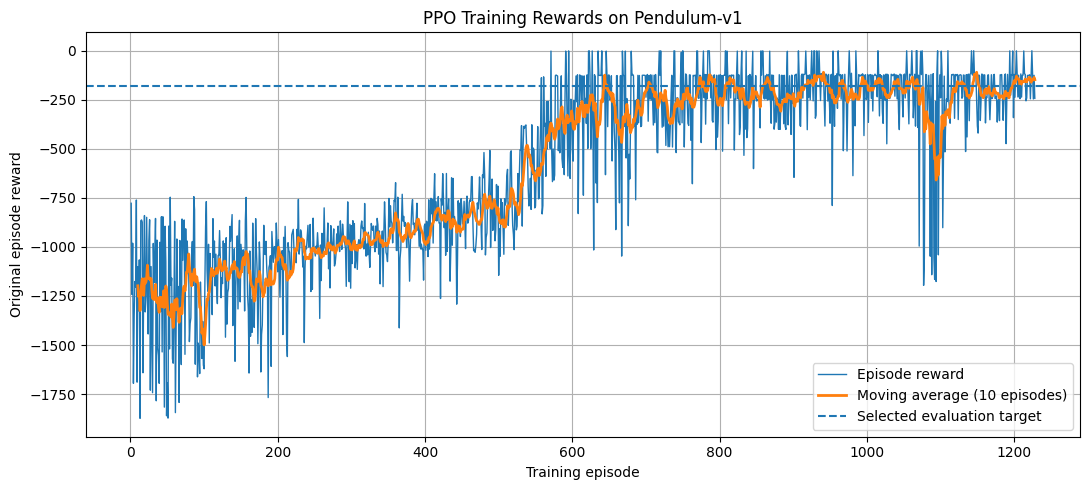

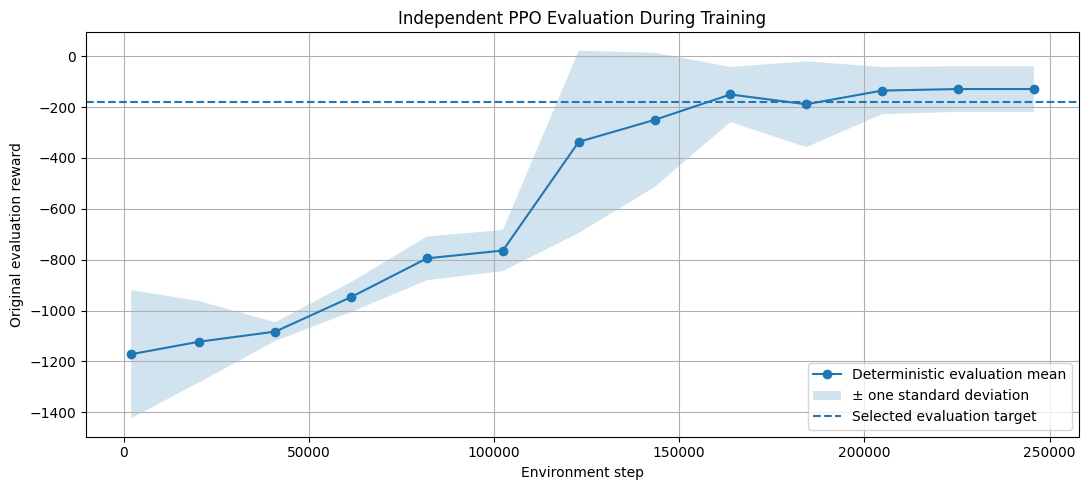

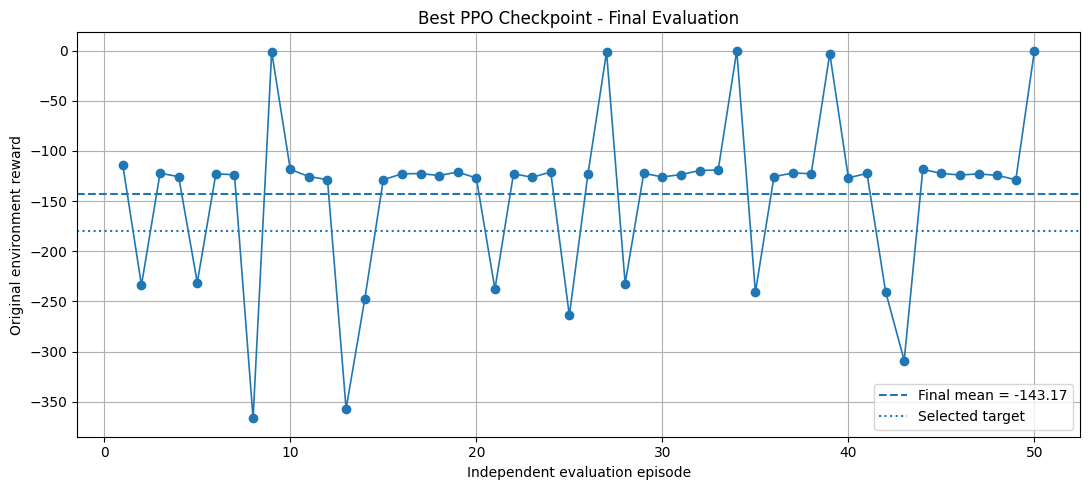

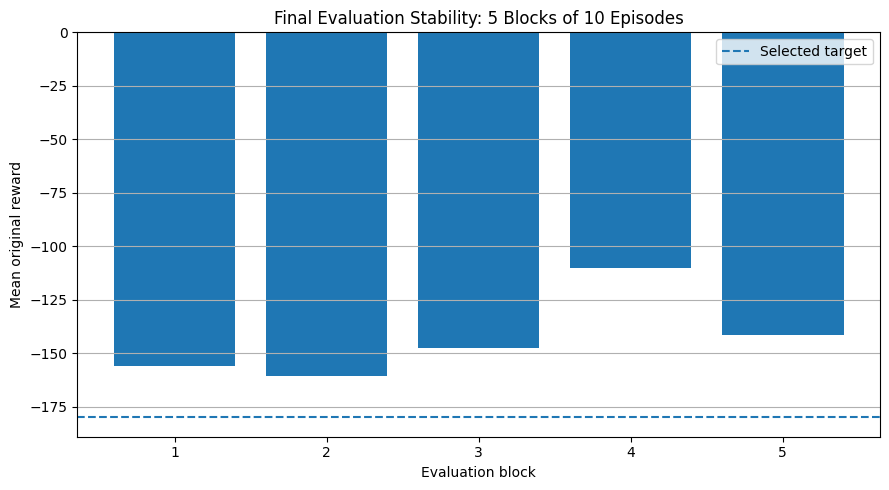

Saved plot: ppo_pendulum_outputs_corrected/ppo_training_rewards.png
Saved plot: ppo_pendulum_outputs_corrected/ppo_checkpoint_evaluations.png
Saved plot: ppo_pendulum_outputs_corrected/ppo_final_evaluation.png
Saved plot: ppo_pendulum_outputs_corrected/ppo_final_block_stability.png


In [7]:
# ============================================================
# 7) Plots
# ============================================================
plt.figure(figsize=(11, 5))
plt.plot(
    np.arange(1, len(episode_rewards) + 1),
    episode_rewards,
    linewidth=1.0,
    label="Episode reward",
)

if len(episode_rewards) >= 10:
    moving_average = np.convolve(
        episode_rewards,
        np.ones(10) / 10.0,
        mode="valid",
    )
    plt.plot(
        np.arange(10, len(episode_rewards) + 1),
        moving_average,
        linewidth=2.0,
        label="Moving average (10 episodes)",
    )

plt.axhline(
    cfg.target_mean_reward,
    linestyle="--",
    label="Selected evaluation target",
)
plt.xlabel("Training episode")
plt.ylabel("Original episode reward")
plt.title("PPO Training Rewards on Pendulum-v1")
plt.grid(True)
plt.legend()
plt.tight_layout()

training_plot_path = output_dir / "ppo_training_rewards.png"
plt.savefig(training_plot_path, dpi=150)
plt.show()

if eval_history:
    eval_steps = np.asarray(
        [row["global_step"] for row in eval_history]
    )
    eval_means = np.asarray(
        [row["mean_reward"] for row in eval_history]
    )
    eval_stds = np.asarray(
        [row["std_reward"] for row in eval_history]
    )

    plt.figure(figsize=(11, 5))
    plt.plot(
        eval_steps,
        eval_means,
        marker="o",
        label="Deterministic evaluation mean",
    )
    plt.fill_between(
        eval_steps,
        eval_means - eval_stds,
        eval_means + eval_stds,
        alpha=0.2,
        label="± one standard deviation",
    )
    plt.axhline(
        cfg.target_mean_reward,
        linestyle="--",
        label="Selected evaluation target",
    )
    plt.xlabel("Environment step")
    plt.ylabel("Original evaluation reward")
    plt.title("Independent PPO Evaluation During Training")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    evaluation_plot_path = output_dir / "ppo_checkpoint_evaluations.png"
    plt.savefig(evaluation_plot_path, dpi=150)
    plt.show()

plt.figure(figsize=(11, 5))
plt.plot(
    np.arange(1, len(final_scores) + 1),
    final_scores,
    marker="o",
    linewidth=1.2,
)
plt.axhline(
    final_mean,
    linestyle="--",
    label=f"Final mean = {final_mean:.2f}",
)
plt.axhline(
    cfg.target_mean_reward,
    linestyle=":",
    label="Selected target",
)
plt.xlabel("Independent evaluation episode")
plt.ylabel("Original environment reward")
plt.title("Best PPO Checkpoint - Final Evaluation")
plt.grid(True)
plt.legend()
plt.tight_layout()

final_plot_path = output_dir / "ppo_final_evaluation.png"
plt.savefig(final_plot_path, dpi=150)
plt.show()

plt.figure(figsize=(9, 5))
block_numbers = [row["block"] for row in block_results]
block_means = [row["mean_reward"] for row in block_results]

plt.bar(block_numbers, block_means)
plt.axhline(
    cfg.target_mean_reward,
    linestyle="--",
    label="Selected target",
)
plt.xlabel("Evaluation block")
plt.ylabel("Mean original reward")
plt.title(
    f"Final Evaluation Stability: "
    f"{cfg.final_blocks} Blocks of {block_size} Episodes"
)
plt.xticks(block_numbers)
plt.grid(True, axis="y")
plt.legend()
plt.tight_layout()

block_plot_path = output_dir / "ppo_final_block_stability.png"
plt.savefig(block_plot_path, dpi=150)
plt.show()

print("Saved plot:", training_plot_path)
if eval_history:
    print("Saved plot:", evaluation_plot_path)
print("Saved plot:", final_plot_path)
print("Saved plot:", block_plot_path)


In [8]:
# ============================================================
# 8) Save the selected final model and create a video
# ============================================================
selected_model_path = output_dir / "selected_best_ppo_pendulum.pt"
torch.save(agent.state_dict(), selected_model_path)

video_path = output_dir / "ppo_pendulum_best_checkpoint.mp4"

video_evaluation = evaluate_policy(
    agent,
    episodes=1,
    seed_start=90_000,
    deterministic=True,
    render_video_path=str(video_path),
)

print("Saved selected model:", selected_model_path)
print("Saved video:", video_path)
print(
    "Video episode original reward:",
    f"{video_evaluation['mean']:.3f}",
)

if Video is not None and display is not None and video_path.exists():
    display(Video(str(video_path), embed=True))


Saved selected model: ppo_pendulum_outputs_corrected/selected_best_ppo_pendulum.pt
Saved video: ppo_pendulum_outputs_corrected/ppo_pendulum_best_checkpoint.mp4
Video episode original reward: -125.402
